# Latent Manifold Plot: A Pedagogical Scaffold

This notebook breaks the latent manifold plot into smaller visual steps.

The aim is to answer three questions:

1. What are we feeding into PCA?
2. What does `all_heads` versus `cardio_only` mean?
3. What is the silhouette score actually measuring?

The examples here are toy data, but the pipeline mirrors the real code in `run/train_sep_vae.py`:

- encode normal and cardiomegaly images
- take encoder means `mu_common` and `mu_cardio`
- spatially average them into pooled vectors
- build `all_heads = [z_common, z_cardio]` and `cardio_only = z_cardio`
- run PCA to 2D
- compute silhouette score on the 2D points

## Roadmap of the plots

We will build up to the final manifold plot in stages:

1. **Latent mean maps** for a few toy images
2. **Spatial pooling** from map to vector
3. **Feature matrix** across many images
4. **Raw latent scatter** before PCA
5. **PCA manifold plots** for `all_heads` and `cardio_only`
6. **Silhouette score** for one example point and then for the whole plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use('default')
np.set_printoptions(precision=3, suppress=True)

In [2]:
rng = np.random.default_rng(3)

H, W = 6, 6
C_COMMON = 3
C_CARDIO = 2
N_PER_CLASS = 80

yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]

common_template = np.stack([
    0.8 * xx,
    -0.6 * yy,
    0.4 * (xx + yy),
], axis=-1)

cardio_bump = np.exp(-4.0 * (xx**2 + yy**2))
cardio_template = np.stack([
    cardio_bump,
    0.7 * cardio_bump - 0.2 * xx,
], axis=-1)

def sample_common_maps(n, class_shift=0.0):
    noise = rng.normal(scale=0.35, size=(n, H, W, C_COMMON))
    shifts = rng.normal(loc=class_shift, scale=0.25, size=(n, 1, 1, C_COMMON))
    return common_template[None, :, :, :] + shifts + noise

def sample_cardio_maps(n, active):
    noise = rng.normal(scale=0.20 if active else 0.14, size=(n, H, W, C_CARDIO))
    if active:
        amp = rng.normal(loc=1.0, scale=0.15, size=(n, 1, 1, C_CARDIO))
        return amp * cardio_template[None, :, :, :] + noise
    amp = rng.normal(loc=0.05, scale=0.05, size=(n, 1, 1, C_CARDIO))
    return amp * cardio_template[None, :, :, :] + noise

mu_common_normal = sample_common_maps(N_PER_CLASS, class_shift=0.0)
mu_common_cardio = sample_common_maps(N_PER_CLASS, class_shift=0.08)

mu_cardio_normal = sample_cardio_maps(N_PER_CLASS, active=False)
mu_cardio_cardio = sample_cardio_maps(N_PER_CLASS, active=True)

labels = np.array([0] * N_PER_CLASS + [1] * N_PER_CLASS)
label_names = {0: 'Normal', 1: 'Cardiomegaly'}

mu_common_all = np.concatenate([mu_common_normal, mu_common_cardio], axis=0)
mu_cardio_all = np.concatenate([mu_cardio_normal, mu_cardio_cardio], axis=0)

## 1. Latent mean maps

These are toy versions of the encoder mean maps.

- `mu_common(x)` should mostly reflect shared structure
- `mu_cardio(x)` should be weak for normal images and stronger for cardiomegaly images

To keep the plot simple, we average over channels and show one heatmap per head.

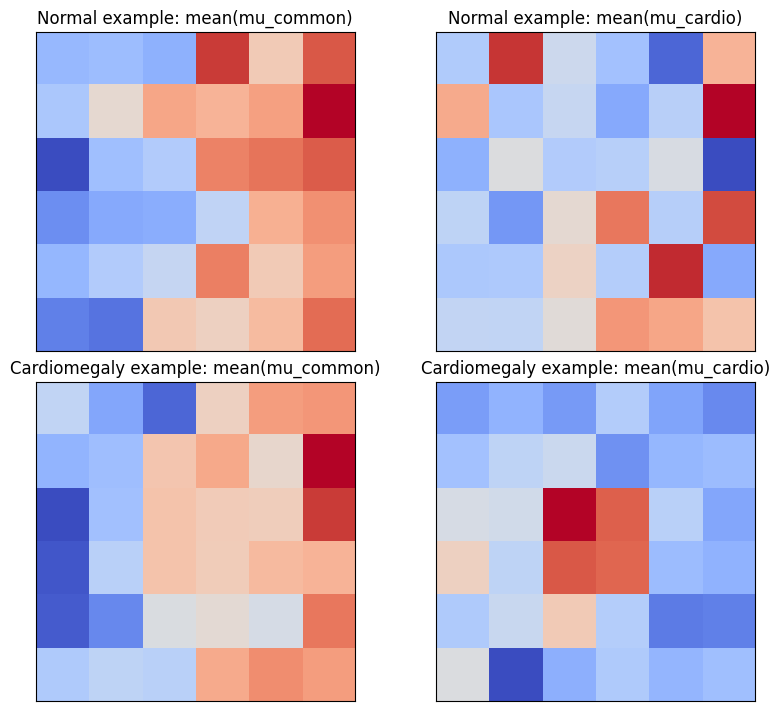

In [3]:
def mean_over_channels(x):
    return x.mean(axis=-1)

example_ids = [0, N_PER_CLASS]
titles = ['Normal example', 'Cardiomegaly example']

fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
for row, idx in enumerate(example_ids):
    axes[row, 0].imshow(mean_over_channels(mu_common_all[idx]), cmap='coolwarm')
    axes[row, 0].set_title(f'{titles[row]}: mean(mu_common)')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    axes[row, 1].imshow(mean_over_channels(mu_cardio_all[idx]), cmap='coolwarm')
    axes[row, 1].set_title(f'{titles[row]}: mean(mu_cardio)')
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])

plt.show()

## 2. Spatial pooling: map to vector

The real plot does not directly use the full spatial map.
It averages over height and width:

$$
z_{common} = \operatorname{mean}_{h,w}(\mu_{common}),
\qquad
z_{cardio} = \operatorname{mean}_{h,w}(\mu_{cardio})
$$

So each image becomes two vectors: one pooled common vector and one pooled cardio vector.

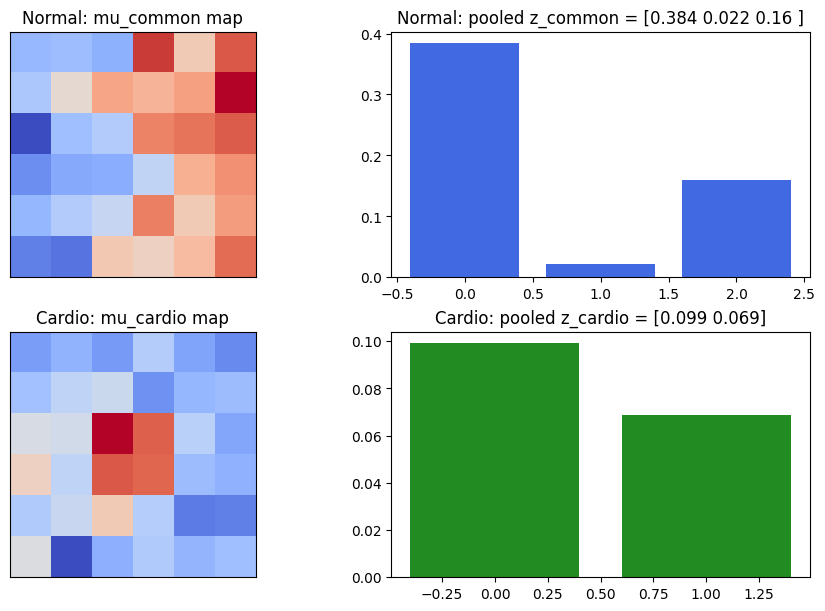

In [4]:
z_common = mu_common_all.mean(axis=(1, 2))
z_cardio = mu_cardio_all.mean(axis=(1, 2))

idx_normal = 0
idx_cardio = N_PER_CLASS

fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True)
axes[0, 0].imshow(mean_over_channels(mu_common_all[idx_normal]), cmap='coolwarm')
axes[0, 0].set_title('Normal: mu_common map')
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])
axes[0, 1].bar(np.arange(C_COMMON), z_common[idx_normal], color='royalblue')
axes[0, 1].set_title(f'Normal: pooled z_common = {z_common[idx_normal]}')

axes[1, 0].imshow(mean_over_channels(mu_cardio_all[idx_cardio]), cmap='coolwarm')
axes[1, 0].set_title('Cardio: mu_cardio map')
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
axes[1, 1].bar(np.arange(C_CARDIO), z_cardio[idx_cardio], color='forestgreen')
axes[1, 1].set_title(f'Cardio: pooled z_cardio = {z_cardio[idx_cardio]}')

plt.show()

## 3. The feature matrix before PCA

At this point each row is one image.

- `all_heads` uses `[z_common, z_cardio]`
- `cardio_only` uses just `z_cardio`

This heatmap helps show where class structure lives before PCA.

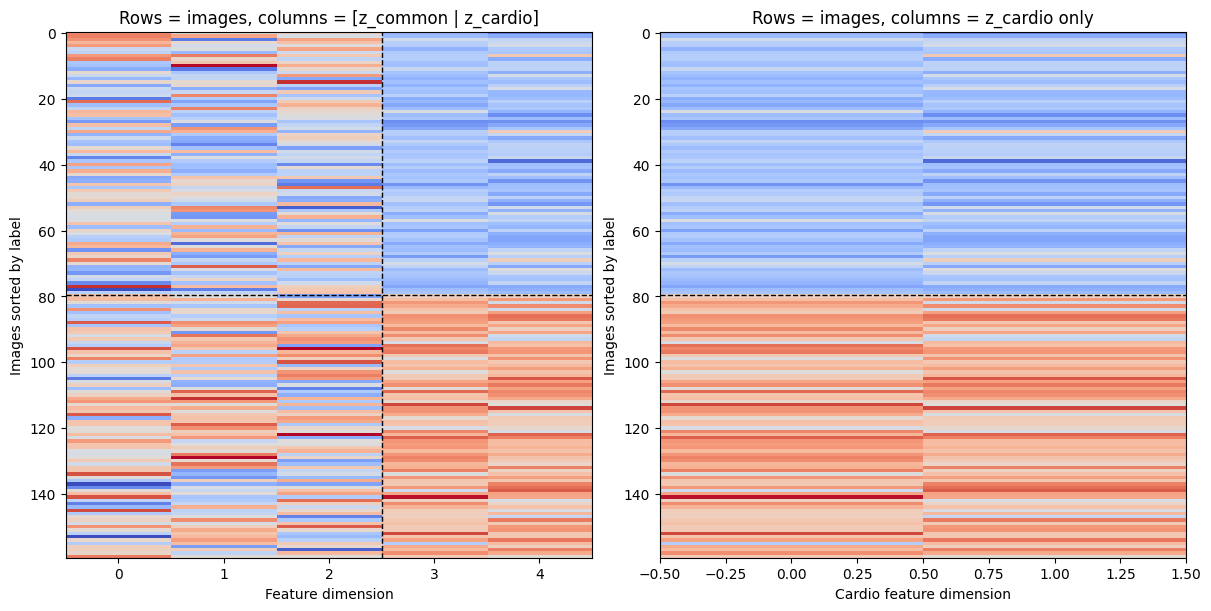

In [5]:
all_heads = np.concatenate([z_common, z_cardio], axis=1)
cardio_only = z_cardio

sort_idx = np.argsort(labels)
all_heads_sorted = all_heads[sort_idx]
cardio_sorted = cardio_only[sort_idx]

def standardize_columns(x):
    return (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(standardize_columns(all_heads_sorted), aspect='auto', cmap='coolwarm', vmin=-2.5, vmax=2.5)
axes[0].axvline(C_COMMON - 0.5, color='black', linestyle='--', linewidth=1)
axes[0].axhline(N_PER_CLASS - 0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Rows = images, columns = [z_common | z_cardio]')
axes[0].set_xlabel('Feature dimension')
axes[0].set_ylabel('Images sorted by label')

axes[1].imshow(standardize_columns(cardio_sorted), aspect='auto', cmap='coolwarm', vmin=-2.5, vmax=2.5)
axes[1].axhline(N_PER_CLASS - 0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Rows = images, columns = z_cardio only')
axes[1].set_xlabel('Cardio feature dimension')
axes[1].set_ylabel('Images sorted by label')

plt.show()

## 4. Raw latent scatter before PCA

In this toy setup the cardio head has exactly 2 pooled dimensions, so we can scatter it directly without PCA.

This is not always possible in the real model, because the pooled vectors are higher-dimensional. That is why PCA is used there.

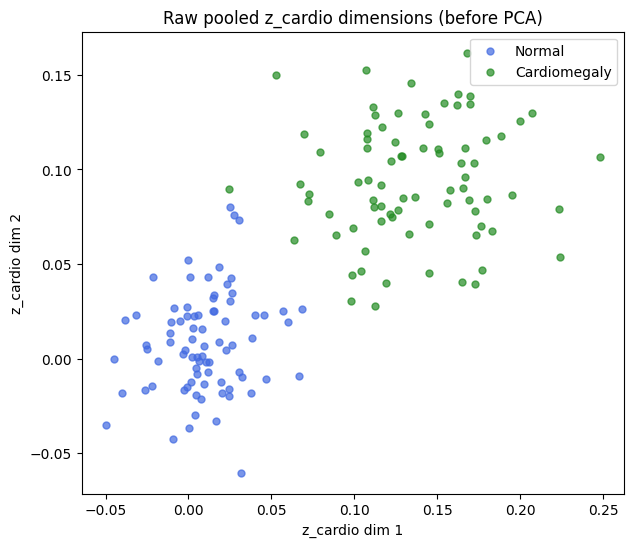

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
for cls, color, name in [(0, 'royalblue', 'Normal'), (1, 'forestgreen', 'Cardiomegaly')]:
    mask = labels == cls
    ax.scatter(cardio_only[mask, 0], cardio_only[mask, 1], s=25, alpha=0.7, color=color, label=name)
ax.set_title('Raw pooled z_cardio dimensions (before PCA)')
ax.set_xlabel('z_cardio dim 1')
ax.set_ylabel('z_cardio dim 2')
ax.legend()
plt.show()

## 5. PCA manifold plots

Now we do the same thing as the training visualization:

- PCA on `all_heads`
- PCA on `cardio_only`

Each point is still one image. PCA is just compressing the feature vectors down to 2D so they can be plotted.

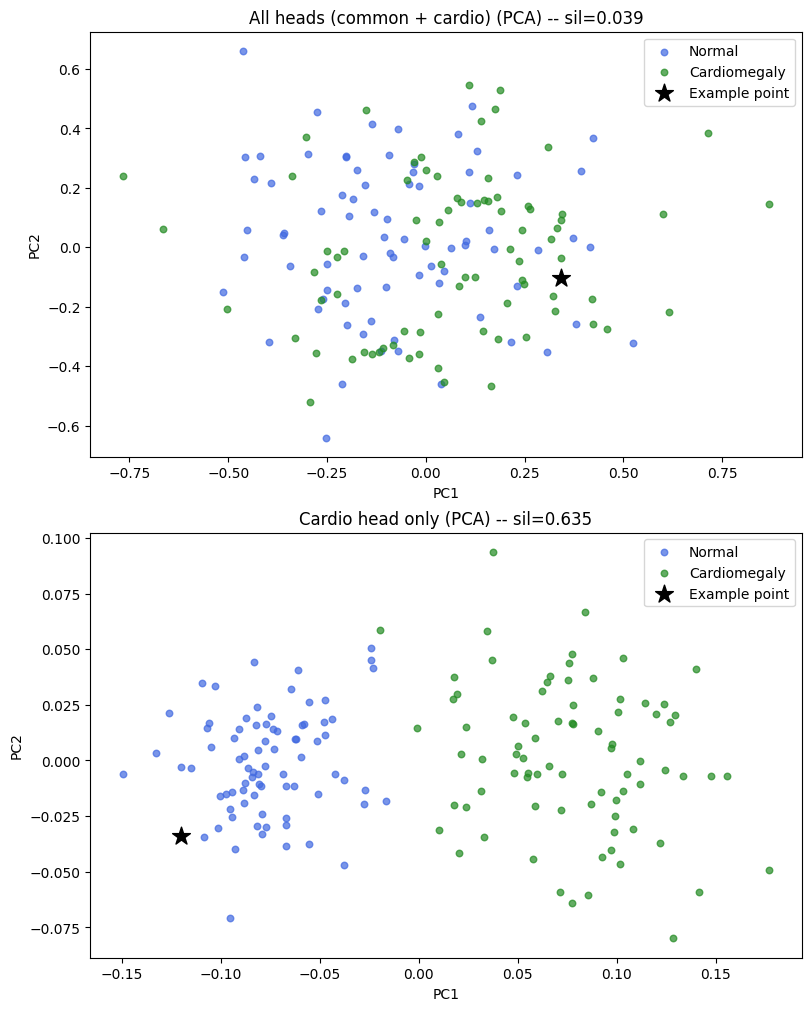

all_heads silhouette   = 0.039
cardio_only silhouette = 0.635


In [7]:
all_heads_2d = PCA(n_components=2, random_state=42).fit_transform(all_heads)
cardio_only_2d = PCA(n_components=2, random_state=42).fit_transform(cardio_only)

sil_all = silhouette_score(all_heads_2d, labels)
sil_cardio = silhouette_score(cardio_only_2d, labels)

def plot_embedding(ax, points, labels, title, highlight_idx=0):
    for cls, color, name in [(0, 'royalblue', 'Normal'), (1, 'forestgreen', 'Cardiomegaly')]:
        mask = labels == cls
        ax.scatter(points[mask, 0], points[mask, 1], s=22, alpha=0.7, color=color, label=name)
    ax.scatter(points[highlight_idx, 0], points[highlight_idx, 1], marker='*', s=180, color='black', label='Example point')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='best')

fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)
plot_embedding(axes[0], all_heads_2d, labels, f'All heads (common + cardio) (PCA) -- sil={sil_all:.3f}')
plot_embedding(axes[1], cardio_only_2d, labels, f'Cardio head only (PCA) -- sil={sil_cardio:.3f}')
plt.show()

print(f'all_heads silhouette   = {sil_all:.3f}')
print(f'cardio_only silhouette = {sil_cardio:.3f}')

## 6. Where the silhouette score comes from

For one point $i$:

$$
a(i) = \text{average distance to points in the same class}
$$

$$
b(i) = \text{average distance to points in the other class}
$$

$$
sil(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Then the final silhouette score is the average of `sil(i)` over all plotted points.

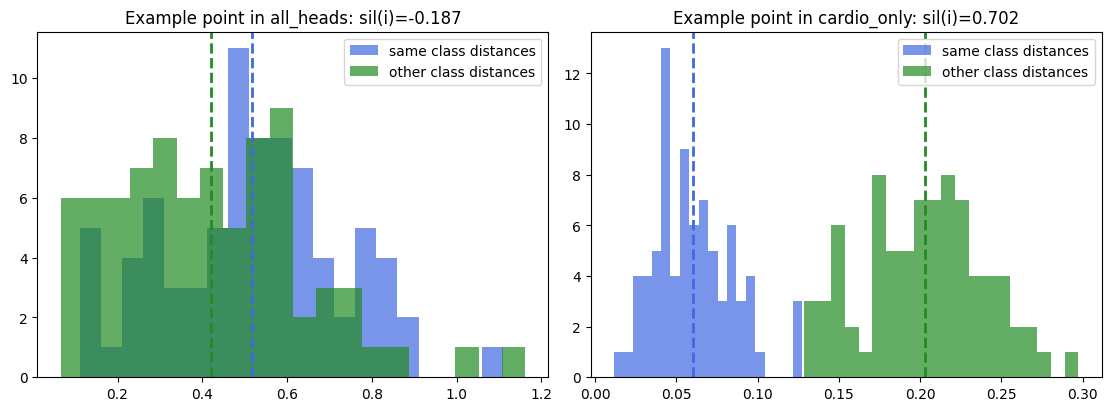

Example point: all_heads
  a(i) = 0.518
  b(i) = 0.421
  sil(i) = (b-a)/max(a,b) = -0.187

Example point: cardio_only
  a(i) = 0.060
  b(i) = 0.203
  sil(i) = (b-a)/max(a,b) = 0.702


In [8]:
def silhouette_for_point(points, labels, idx):
    point = points[idx]
    same = points[labels == labels[idx]]
    other = points[labels != labels[idx]]

    same_dist = np.linalg.norm(same - point, axis=1)
    same_dist = same_dist[same_dist > 0]
    other_dist = np.linalg.norm(other - point, axis=1)

    a_i = same_dist.mean()
    b_i = other_dist.mean()
    sil_i = (b_i - a_i) / max(a_i, b_i)
    return a_i, b_i, sil_i, same_dist, other_dist

a_all, b_all, sil_i_all, same_all, other_all = silhouette_for_point(all_heads_2d, labels, 0)
a_card, b_card, sil_i_card, same_card, other_card = silhouette_for_point(cardio_only_2d, labels, 0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].hist(same_all, bins=20, alpha=0.7, color='royalblue', label='same class distances')
axes[0].hist(other_all, bins=20, alpha=0.7, color='forestgreen', label='other class distances')
axes[0].axvline(a_all, color='royalblue', linestyle='--', linewidth=2)
axes[0].axvline(b_all, color='forestgreen', linestyle='--', linewidth=2)
axes[0].set_title(f'Example point in all_heads: sil(i)={sil_i_all:.3f}')
axes[0].legend()

axes[1].hist(same_card, bins=20, alpha=0.7, color='royalblue', label='same class distances')
axes[1].hist(other_card, bins=20, alpha=0.7, color='forestgreen', label='other class distances')
axes[1].axvline(a_card, color='royalblue', linestyle='--', linewidth=2)
axes[1].axvline(b_card, color='forestgreen', linestyle='--', linewidth=2)
axes[1].set_title(f'Example point in cardio_only: sil(i)={sil_i_card:.3f}')
axes[1].legend()

plt.show()

print('Example point: all_heads')
print(f'  a(i) = {a_all:.3f}')
print(f'  b(i) = {b_all:.3f}')
print(f'  sil(i) = (b-a)/max(a,b) = {sil_i_all:.3f}')
print()
print('Example point: cardio_only')
print(f'  a(i) = {a_card:.3f}')
print(f'  b(i) = {b_card:.3f}')
print(f'  sil(i) = (b-a)/max(a,b) = {sil_i_card:.3f}')

## 7. What you should take away

The final manifold plot is not showing the raw image space. It is showing where the encoder places images **after**:

- encoding into latent mean maps
- spatially pooling those maps into vectors
- optionally concatenating heads
- projecting those vectors to 2D with PCA

So the two panels answer slightly different questions:

- `all_heads`: if I use both common and disease features together, how separable do normal and cardio look?
- `cardio_only`: if I look only at the disease head, how separable do normal and cardio look?

If `cardio_only` has the higher silhouette score, that usually supports the intended decomposition:

$$
z_{common} = \text{shared structure},
\qquad
z_{cardio} = \text{class-relevant disease residual}.
$$

The most important caveat is the same as in the real training code: the silhouette score is computed on the **2D PCA projection**, so it is a useful diagnostic rather than a proof about the full latent geometry.